# Telco Customer Churn Analytics
## 02 - Exploratory Data Analysis

This notebook explores customer behavior, churn patterns,
tenure, monthly charges, contracts, internet services,
payment methods, and customer segments.

### Objectives
- Understand the overall customer base
- Analyze churn distribution
- Identify churn patterns across customer segments
- Analyze tenure and monthly charges
- Examine services associated with churn
- Generate portfolio-ready visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned/telco_churn_cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Monthly_Charges_Group,Senior_Citizen_Status,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,Under $30,Non-Senior Citizen,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,$30-$59,Non-Senior Citizen,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,$30-$59,Non-Senior Citizen,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,$30-$59,Non-Senior Citizen,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,$60-$89,Non-Senior Citizen,1


In [4]:
df.shape

(7043, 25)

In [5]:
tenure_order = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-60 Months",
    "60+ Months"
]

charge_order = [
    "Under $30",
    "$30-$59",
    "$60-$89",
    "$90+"
]

df["Tenure_Group"] = pd.Categorical(
    df["Tenure_Group"],
    categories=tenure_order,
    ordered=True
)

df["Monthly_Charges_Group"] = pd.Categorical(
    df["Monthly_Charges_Group"],
    categories=charge_order,
    ordered=True
)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   customerID             7043 non-null   str     
 1   gender                 7043 non-null   str     
 2   SeniorCitizen          7043 non-null   int64   
 3   Partner                7043 non-null   str     
 4   Dependents             7043 non-null   str     
 5   tenure                 7043 non-null   int64   
 6   PhoneService           7043 non-null   str     
 7   MultipleLines          7043 non-null   str     
 8   InternetService        7043 non-null   str     
 9   OnlineSecurity         7043 non-null   str     
 10  OnlineBackup           7043 non-null   str     
 11  DeviceProtection       7043 non-null   str     
 12  TechSupport            7043 non-null   str     
 13  StreamingTV            7043 non-null   str     
 14  StreamingMovies        7043 non-null   str     
 15

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [8]:
df.describe(include="object")

C:\Users\User\AppData\Local\Temp\ipykernel_26488\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,Senior_Citizen_Status
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Non-Senior Citizen
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174,5901


In [9]:
total_customers = df["customerID"].nunique()

churned_customers = df["Churn_Flag"].sum()

retained_customers = total_customers - churned_customers

churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %


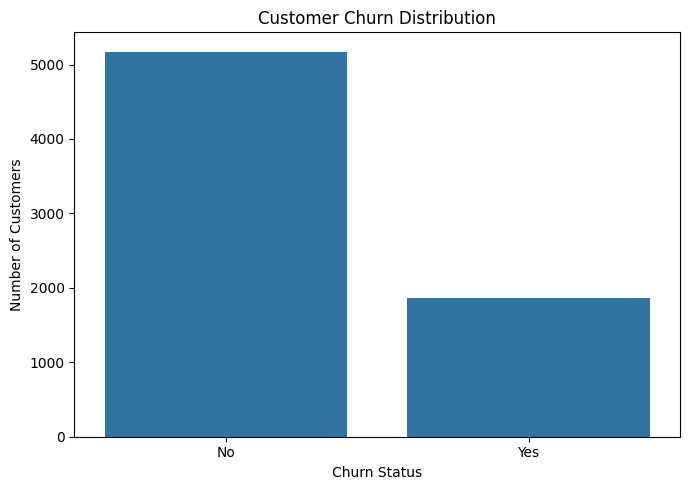

In [45]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
contract_churn = (
    df.groupby("Contract", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

contract_churn

,Contract,Churn_Flag
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


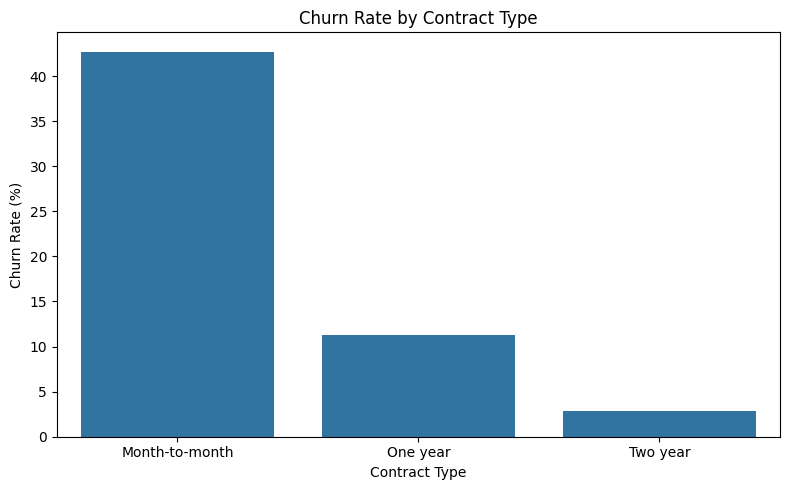

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn_Flag"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    "../images/churn_rate_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
tenure_churn = (
    df.groupby("Tenure_Group", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

tenure_churn

,Tenure_Group,Churn_Flag
0,0-12 Months,47.438243
1,13-24 Months,28.710938
2,25-48 Months,20.388959
3,49-60 Months,14.423077
4,60+ Months,6.609808


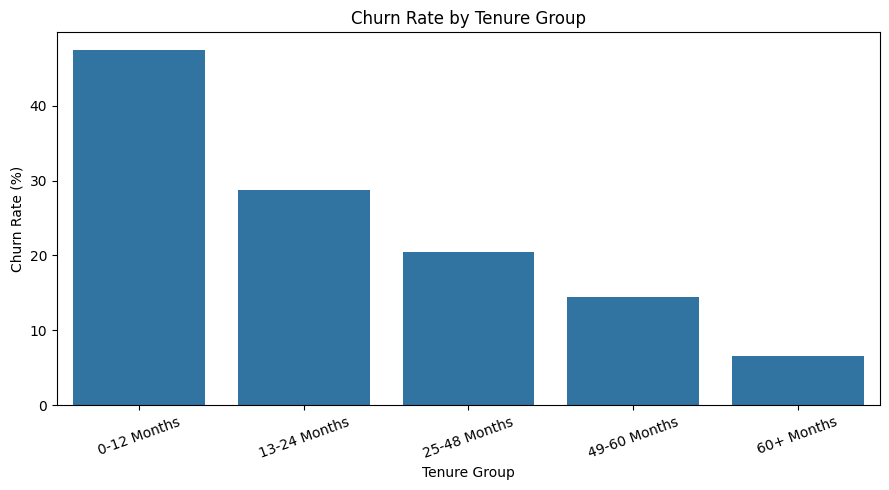

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="Tenure_Group",
    y="Churn_Flag"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/churn_rate_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
internet_churn = (
    df.groupby("InternetService", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

internet_churn

,InternetService,Churn_Flag
0,DSL,18.959108
1,Fiber optic,41.892765
2,No,7.404980


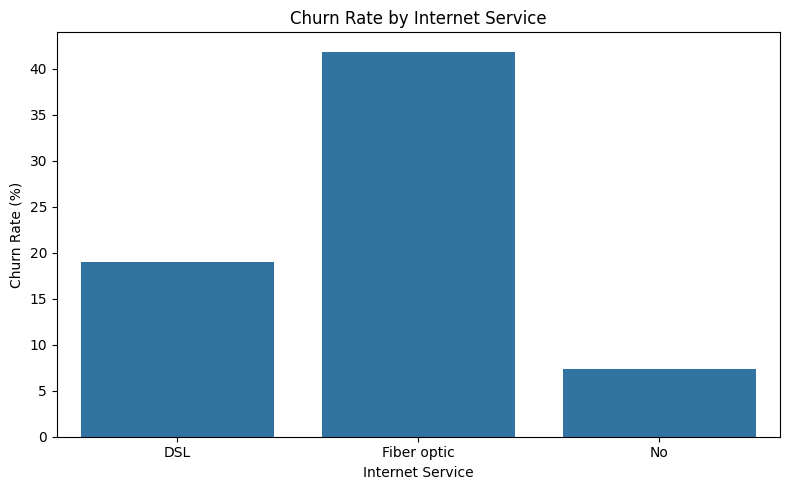

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Churn_Flag"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    "../images/churn_rate_by_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
payment_churn = (
    df.groupby("PaymentMethod", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

payment_churn

,PaymentMethod,Churn_Flag
0,Bank transfer (automatic),16.709845
1,Credit card (automatic),15.243101
2,Electronic check,45.285412
3,Mailed check,19.106700


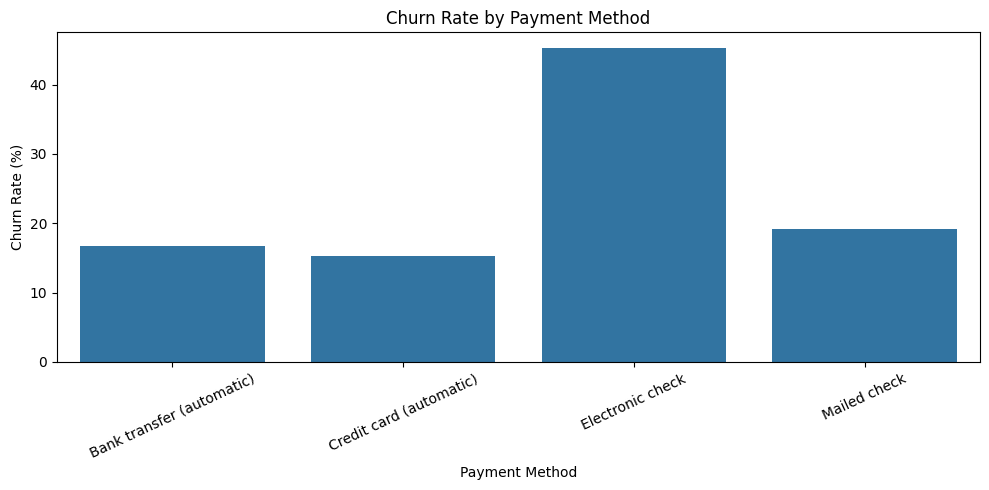

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="Churn_Flag"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(
    "../images/churn_rate_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
senior_churn = (
    df.groupby("Senior_Citizen_Status", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

senior_churn

,Senior_Citizen_Status,Churn_Flag
0,Non-Senior Citizen,23.606168
1,Senior Citizen,41.681261


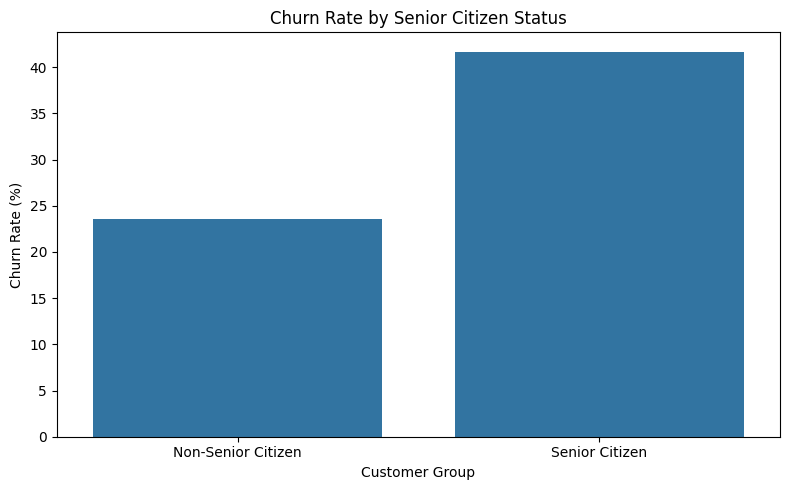

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=senior_churn,
    x="Senior_Citizen_Status",
    y="Churn_Flag"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [21]:
charge_churn = (
    df.groupby("Monthly_Charges_Group", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

charge_churn

,Monthly_Charges_Group,Churn_Flag
0,Under $30,9.800363
1,$30-$59,26.076555
2,$60-$89,33.737458
3,$90+,32.855505


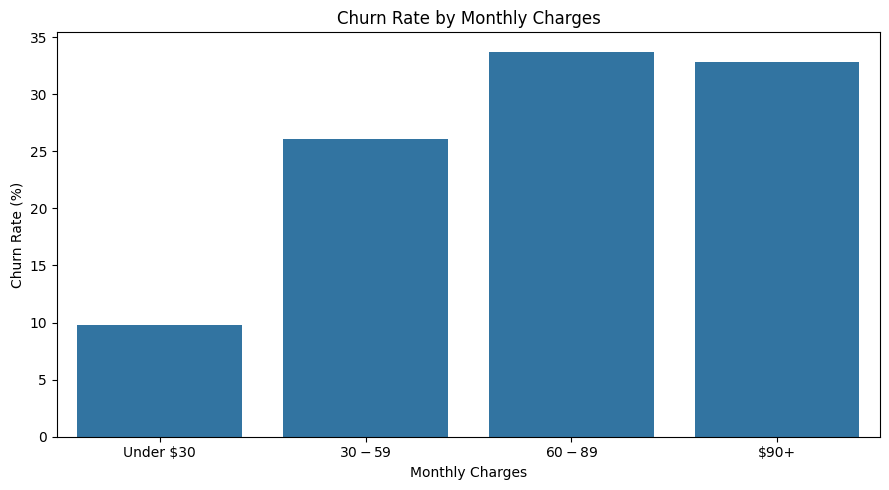

In [50]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=charge_churn,
    x="Monthly_Charges_Group",
    y="Churn_Flag"
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    "../images/churn_rate_by_monthly_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

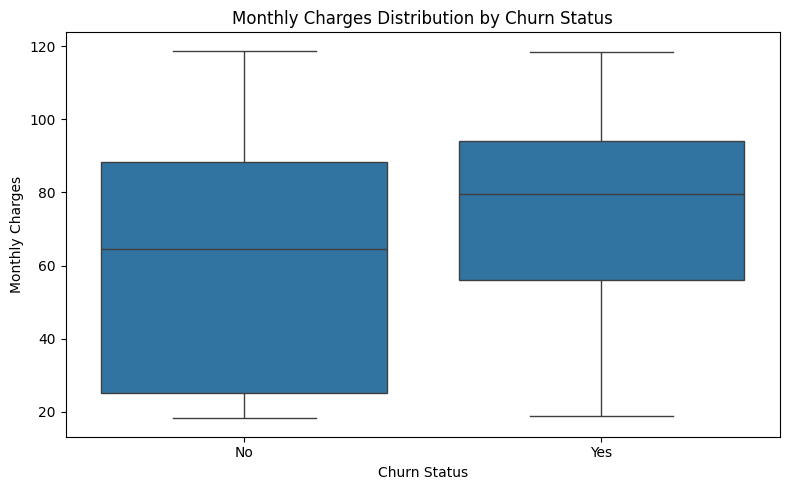

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../images/monthly_charges_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

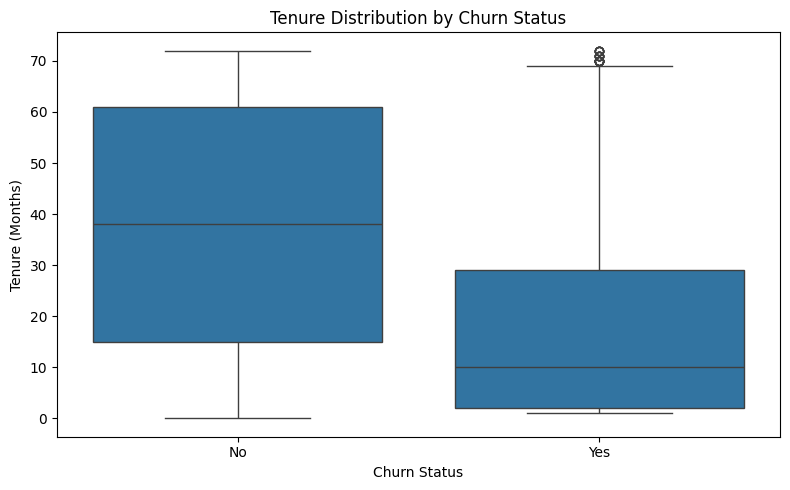

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()

plt.savefig(
    "../images/tenure_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

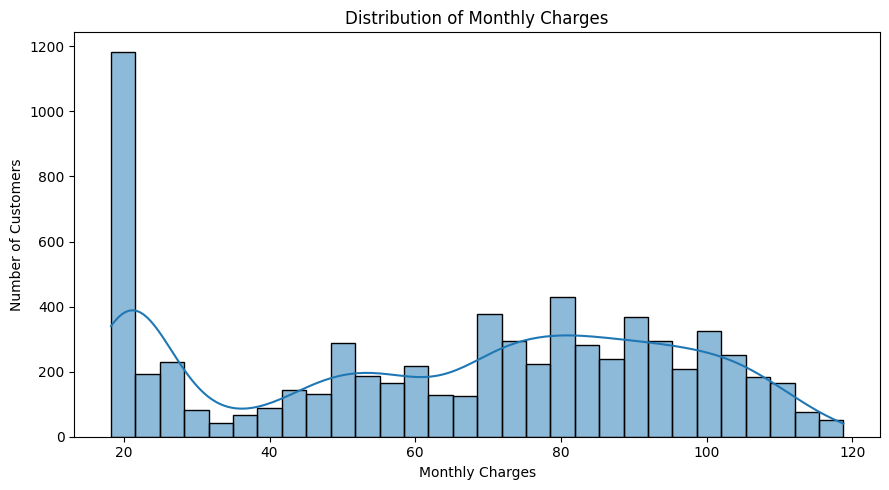

In [25]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

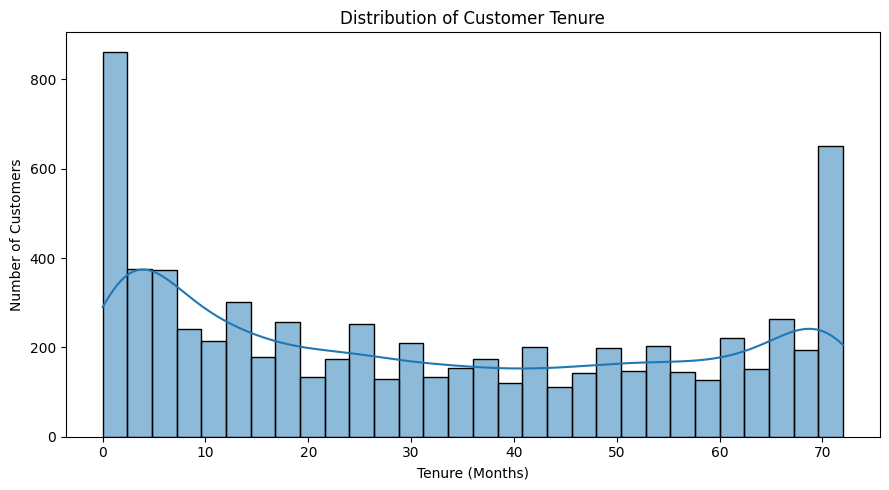

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [27]:
gender_churn = (
    df.groupby("gender")["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

gender_churn

,gender,Churn_Flag
0,Female,26.920872
1,Male,26.160338


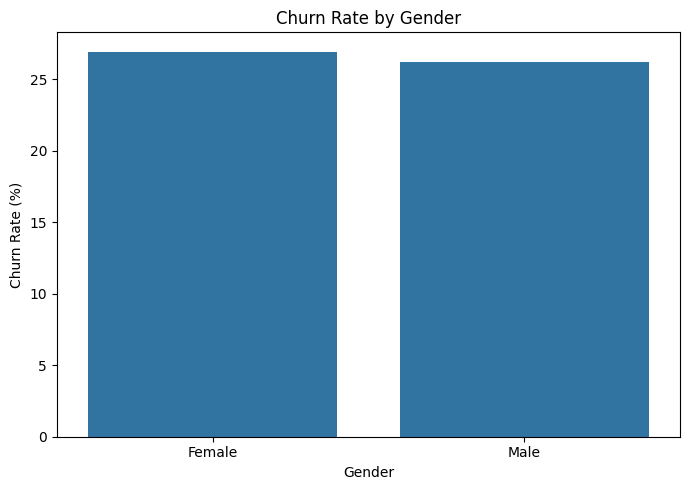

In [28]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn,
    x="gender",
    y="Churn_Flag"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [29]:
partner_churn = (
    df.groupby("Partner")["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

partner_churn

,Partner,Churn_Flag
0,No,32.957979
1,Yes,19.664903


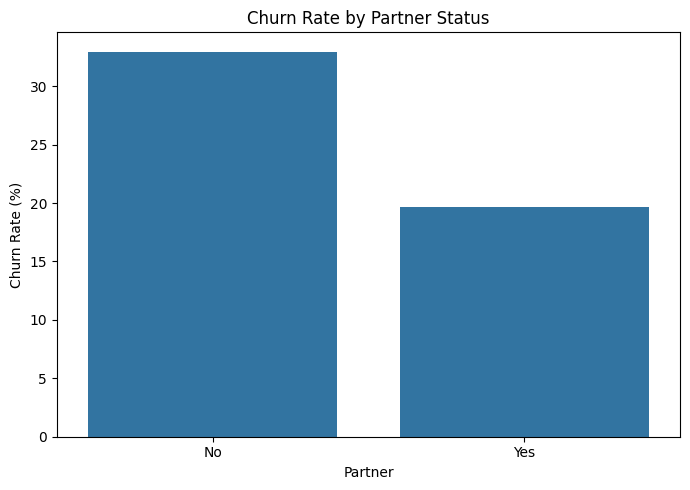

In [30]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=partner_churn,
    x="Partner",
    y="Churn_Flag"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [31]:
dependents_churn = (
    df.groupby("Dependents")["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

dependents_churn

,Dependents,Churn_Flag
0,No,31.279140
1,Yes,15.450237


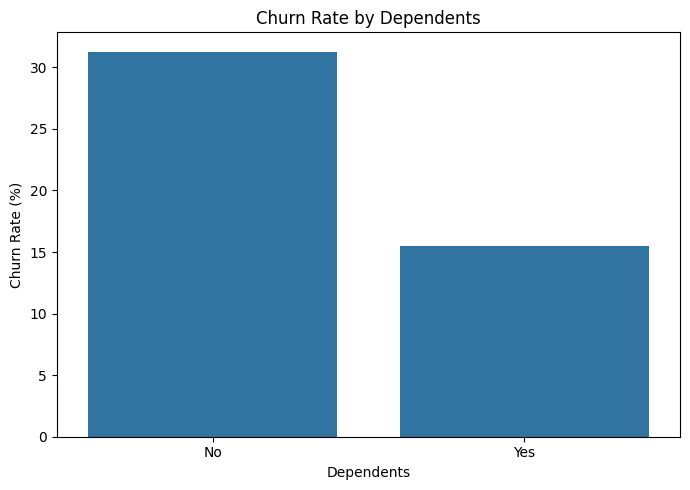

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=dependents_churn,
    x="Dependents",
    y="Churn_Flag"
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [33]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [34]:
for column in service_columns:
    result = (
        df.groupby(column)["Churn_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )
    
    print(f"\n===== {column} =====")
    display(result)


===== OnlineSecurity =====


,OnlineSecurity,Churn_Flag
0,No,41.766724
1,No internet service,7.404980
2,Yes,14.611194



===== OnlineBackup =====


,OnlineBackup,Churn_Flag
0,No,39.928756
1,No internet service,7.404980
2,Yes,21.531494



===== DeviceProtection =====


...

,TechSupport,Churn_Flag
0,No,41.635474
1,No internet service,7.404980
2,Yes,15.166341



===== StreamingTV =====


,StreamingTV,Churn_Flag
0,No,33.523132
1,No internet service,7.404980
2,Yes,30.070188



===== StreamingMovies =====


,StreamingMovies,Churn_Flag
0,No,33.680431
1,No internet service,7.404980
2,Yes,29.941435


In [35]:
contract_internet = (
    df.groupby(
        ["Contract", "InternetService"],
        observed=True
    )["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

contract_internet

,Contract,InternetService,Churn_Flag
0,Month-to-month,DSL,32.215863
1,Month-to-month,Fiber optic,54.605263
2,Month-to-month,No,18.893130
3,One year,DSL,9.298246
4,One year,Fiber optic,19.294991
5,One year,No,2.472527
6,Two year,DSL,1.910828
7,Two year,Fiber optic,7.226107
8,Two year,No,0.783699


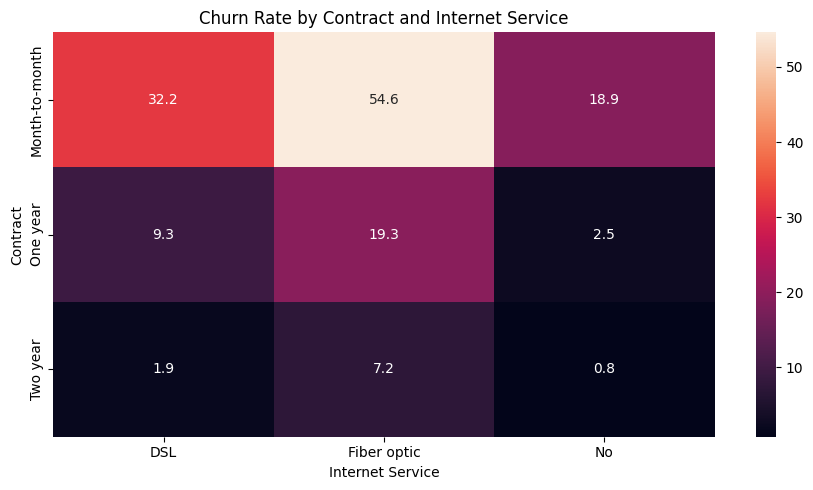

In [44]:
pivot_contract_internet = contract_internet.pivot(
    index="Contract",
    columns="InternetService",
    values="Churn_Flag"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    pivot_contract_internet,
    annot=True,
    fmt=".1f"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract")

plt.tight_layout()

plt.savefig(
    "../images/contract_internet_churn_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
contract_tenure = (
    df.groupby(
        ["Contract", "Tenure_Group"],
        observed=True
    )["Churn_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

contract_tenure.head(20)

,Contract,Tenure_Group,Churn_Flag
0,Month-to-month,0-12 Months,51.354062
1,Month-to-month,13-24 Months,37.720488
2,Month-to-month,25-48 Months,32.917706
3,Month-to-month,49-60 Months,27.777778
4,Month-to-month,60+ Months,22.222222
5,One year,0-12 Months,10.483871
6,One year,13-24 Months,8.121827
7,One year,25-48 Months,10.617761
8,One year,49-60 Months,13.707165
9,One year,60+ Months,12.140575


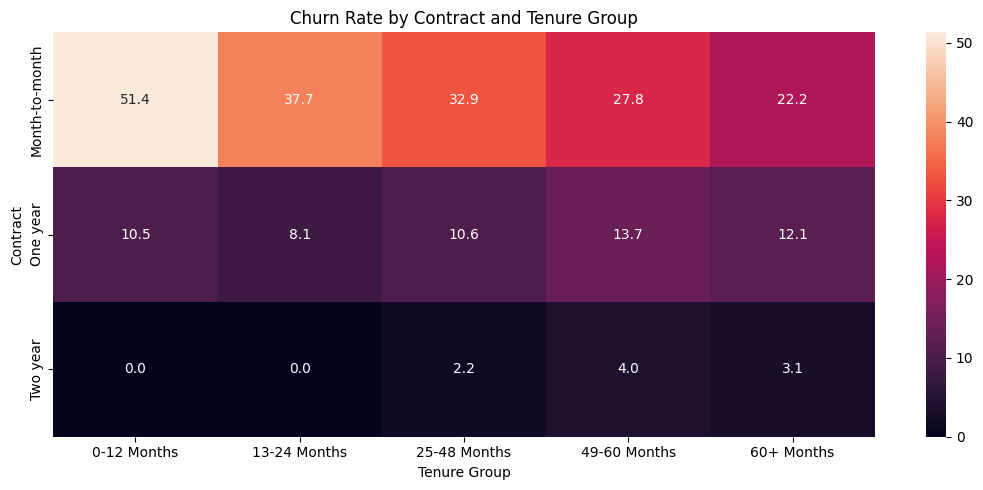

In [43]:
pivot_contract_tenure = contract_tenure.pivot(
    index="Contract",
    columns="Tenure_Group",
    values="Churn_Flag"
)

plt.figure(figsize=(11, 5))

sns.heatmap(
    pivot_contract_tenure,
    annot=True,
    fmt=".1f"
)

plt.title("Churn Rate by Contract and Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Contract")

plt.tight_layout()

plt.savefig(
    "../images/contract_tenure_churn_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Flag"
]

correlation = df[numeric_columns].corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Flag
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn_Flag,0.150889,-0.352229,0.193356,-0.198324,1.000000


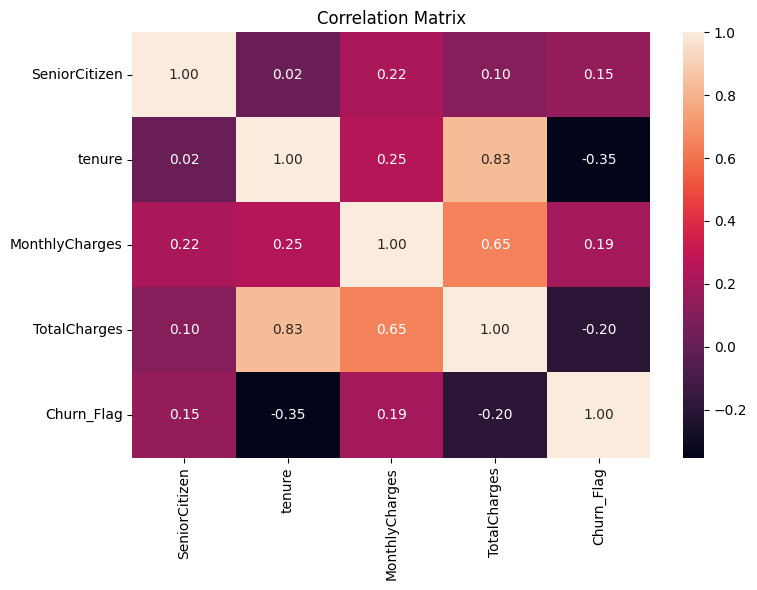

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../images/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
churn_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate",
        "Average Tenure",
        "Average Monthly Charges",
        "Average Total Charges"
    ],
    "Value": [
        df["customerID"].nunique(),
        df["Churn_Flag"].sum(),
        (df["Churn_Flag"] == 0).sum(),
        df["Churn_Flag"].mean() * 100,
        df["tenure"].mean(),
        df["MonthlyCharges"].mean(),
        df["TotalCharges"].mean()
    ]
})

churn_summary

,Metric,Value
0,Total Customers,7043.000000
1,Churned Customers,1869.000000
2,Retained Customers,5174.000000
3,Overall Churn Rate,26.536987
4,Average Tenure,32.371149
5,Average Monthly Charges,64.761692
6,Average Total Charges,2279.734304
